In [1]:
# Gõ dòng này vào cell đầu tiên và bấm Run (Shift + Enter) or Run All
get_ipython().run_line_magic('run', '../_setup.py')

In [3]:
from itertools import combinations
from functools import partial
from typing import Optional

from mlforecast import MLForecast
from mlforecast.target_transforms import GlobalSklearnTransformer
from mlforecast.utils import PredictionIntervals
from scipy import stats
from scipy.stats import pearsonr
from sklearn.metrics import r2_score
from sklearn.preprocessing import FunctionTransformer
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from utilsforecast.feature_engineering import fourier, pipeline, trend

from fpppy.models import LinearRegression

mpl.rcParams['axes.prop_cycle'] = cycler(color=["#569CC6", "#D55F03", "#13A076"])

def plot_diagnostics(
    forecaster,
    model: Optional[str] = None,
    n_lags: int = None,
    target_col: str = "y",
    time_col: str = "ds",
):
    # Plot first model only if no model spec is given
    if model is None:
        model = list(forecaster.models.keys())[0]
    fitted = forecaster.forecast_fitted_values().assign(
        resid=lambda x: x[target_col] - x[model]
    )

    _, axes = plt.subplot_mosaic([["resid", "resid"], ["acf", "hist"]])

    ax = axes["resid"]
    ax.plot(fitted[time_col], fitted["resid"], marker='.')
    ax.set(title="Innovation Residuals")

    ax = axes["acf"]
    plot_acf(
        fitted["resid"], ax=ax, zero=False, lags=n_lags,
        bartlett_confint=False, auto_ylims=True)
    ax.set(title="ACF Plot", xlabel="lag[1]", ylabel='acf')

    ax = axes["hist"]
    ax.hist(fitted["resid"], bins=20)
    ax.set(title="Histogram", xlabel="resid", ylabel="count")

def adj_r2_score(y, y_hat, T, k):
    r2 = r2_score(y, y_hat)
    return 1 - (1 - r2) * (T - 1) / (T - k - 1)

def aic_score(y, y_hat, T, k):
    sse = np.sum((y - y_hat) ** 2)
    return T * np.log(sse / T) + 2 * (k + 2)

def aicc_score(y, y_hat, T, k):
    aic = aic_score(y, y_hat, T, k)
    return aic + (2 * (k + 2) * (k + 3)) / (T - k - 3)

def bic_score(y, y_hat, T, k):
    sse = np.sum((y - y_hat) ** 2)
    return T * np.log(sse / T) + (k + 2) * np.log(T)

def cv_score(mf, model='LinearRegression'):
    fitted_model = mf.models_[model]
    X = fitted_model._X_design
    y = fitted_model._y
    e = fitted_model._residuals
    XtX_inv = np.linalg.pinv(X.T @ X)
    h = np.sum((X @ XtX_inv) * X, axis=1)
    return np.nanmean((e / (1 - h))**2)

In [5]:
def print_regression_summary_from_model(model):
    X = model._X.values.astype(float)
    y = model._y
    resid = model._residuals
    n, p = X.shape
    X_design = np.hstack([np.ones((n, 1)), X])
    dof = n - p - 1

    # residuals summary
    percentiles = [0, 25, 50, 75, 100]
    labels = ["Min", "1Q", "Median", "3Q", "Max"]
    percentiles_resid = np.percentile(resid, percentiles)
    resid_summary = pd.DataFrame({
        label: [percentile]
        for (label, percentile) in zip(labels, percentiles_resid)
    }, index=[""])

    # coefficients summary
    coef = np.insert(model.coef_, 0, model.intercept_)
    rss = np.sum(resid**2)
    mse = rss / dof
    var_beta = mse * np.linalg.inv(X_design.T @ X_design).diagonal()
    se_beta = np.sqrt(var_beta)
    t_stats = coef / se_beta
    p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), dof))
    names = ["(Intercept)"] + model._var_names
    stars_lookup = ["***", "**", "*", "."]
    stars_conds = [
        p_values < 0.001, p_values < 0.01,
        p_values < 0.05, p_values < 0.1]
    stars = np.select(stars_conds, stars_lookup, default="")
    coef_summary = pd.DataFrame({
        "Estimate": coef, "Std. Error": se_beta,
        "t value": t_stats, "Pr(>|t|)": p_values, "": stars
    }, index=names)

    # more statistics
    r_squared = model.score(X, y)
    adj_r_squared = 1 - (1 - r_squared) * (n - 1) / dof
    f_stat = (r_squared / p) / ((1 - r_squared) / dof)
    f_pval = 1 - stats.f.cdf(f_stat, p, dof)

    # print the report
    print(f"Residuals:\n{resid_summary}\n\nCoefficients:\n{coef_summary}")
    print(f"---")
    signif_code_str = "0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1"
    print(f"Signif. codes: {signif_code_str}\n")
    print(
        f"Residual standard error: {np.sqrt(mse):.3f}",
        f"on {dof} degrees of freedom",
        f"\nMultiple R-squared: {r_squared:.3f},   ",
        f"Adjusted R-squared: {adj_r_squared:.3f}",
        f"\nF-statistic: {f_stat:.1f} on {p}",
        f"and {dof} DF, p-value: {f_pval:.3g}")

In [8]:
BASE_DIR = Path.cwd().parent.parent
DATA_DIR = BASE_DIR / "data"
print(DATA_DIR)

/home/phu/Documents/GitHub/-Time-Series-Analysis-and-Forecasting-methods-/data


### 7 Time series regression models

Chapter 7 introduces forecasting time series data assuming a linear relationship with other time series (predictor variables). Here is a comprehensive summary of each section, including the relevant mathematical formulas.


#### 7.1 The linear model
This section introduces the basic concept of regression, where the forecast variable $y$ is modelled as a linear function of one or more predictor variables $x$.

*   **Simple linear regression:** Uses a single predictor variable.
    $$ y_t = \beta_0 + \beta_1 x_t + \varepsilon_t $$
    *(Where $\beta_0$ is the intercept, $\beta_1$ is the slope, and $\varepsilon_t$ is the random error).*
*   **Multiple linear regression:** Uses $k$ predictor variables.
    $$ y_t = \beta_0 + \beta_1 x_{1,t} + \beta_2 x_{2,t} + \dots + \beta_k x_{k,t} + \varepsilon_t $$
    *(The coefficients measure the marginal effects of each predictor after accounting for all others).*
*   **Assumptions:** For the model to be valid, we assume the relationship is linear, predictors are not random, and the errors ($\varepsilon_t$) have a mean of zero, are not autocorrelated, are unrelated to predictors, and ideally are normally distributed with a constant variance $\sigma^2$.

In [9]:
us_change = pd.read_csv(DATA_DIR / "US_change.csv", parse_dates=["ds"])

mf = MLForecast(models=LinearRegression(), freq="QS-OCT")
mf.fit(us_change, fitted=True, static_features=[])
print_regression_summary_from_model(mf.models_['LinearRegression'])

Residuals:
    Min     1Q  Median     3Q    Max
 -0.906 -0.158  -0.036  0.136  1.155

Coefficients:
              Estimate  Std. Error  t value   Pr(>|t|)     
(Intercept)      0.253       0.034    7.343  5.713e-12  ***
Income           0.741       0.040   18.461  0.000e+00  ***
Production       0.047       0.023    2.038  4.287e-02    *
Savings         -0.053       0.003  -18.088  0.000e+00  ***
Unemployment    -0.175       0.096   -1.829  6.895e-02    .
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.310 on 193 degrees of freedom 
Multiple R-squared: 0.768,    Adjusted R-squared: 0.763 
F-statistic: 160.0 on 4 and 193 DF, p-value: 0


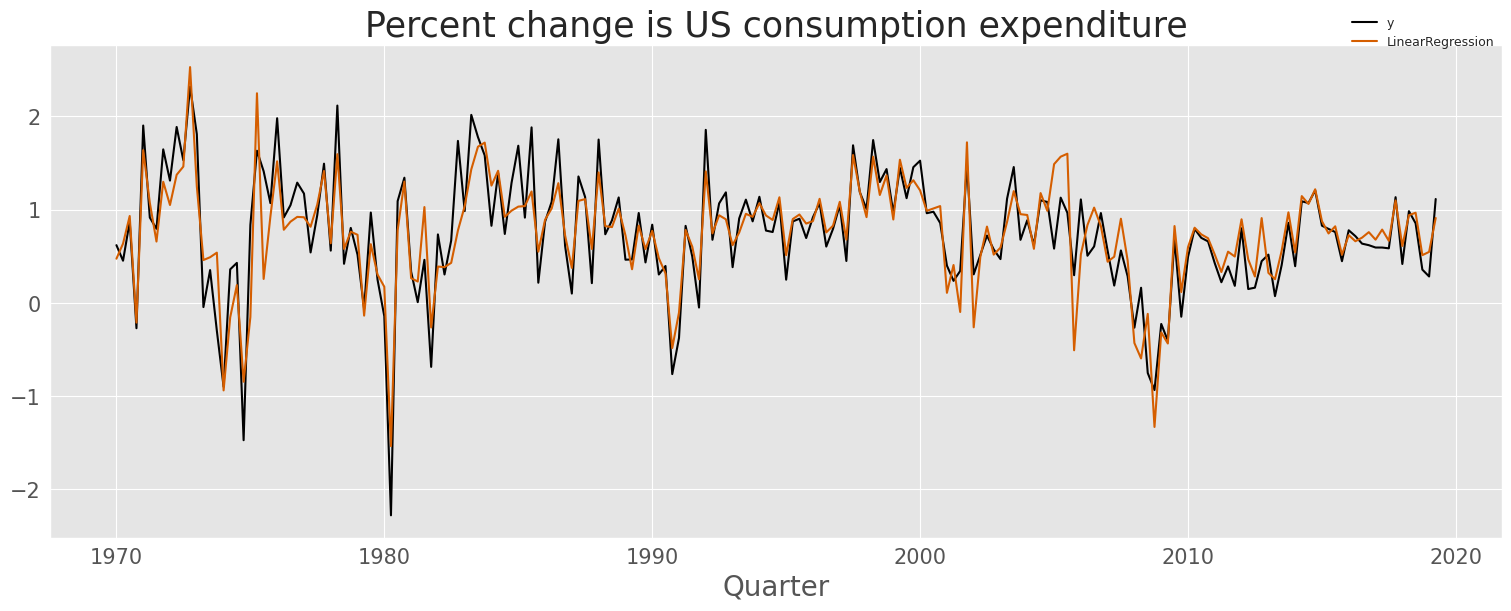

In [11]:
df = mf.forecast_fitted_values().drop(columns="y")
plot_series(us_change, df,
    xlabel="Quarter", ylabel="",
    title="Percent change is US consumption expenditure",
    palette="black_and_orange", rm_legend=False,)

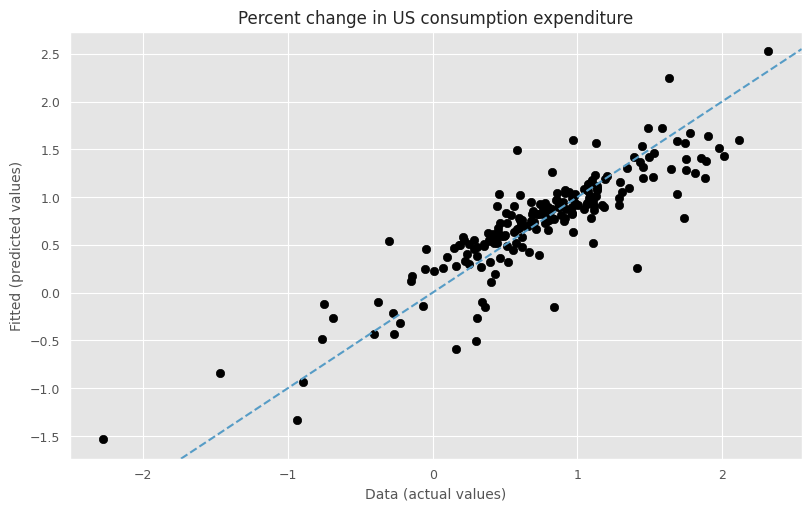

In [12]:
fig, ax = plt.subplots()
insample_forecasts = mf.forecast_fitted_values()["LinearRegression"]
ax.scatter(us_change["y"], insample_forecasts, color="k")
ax.axline((0, 0), (1, 1), linestyle="--")
ax.set(
    title="Percent change in US consumption expenditure",
    xlabel="Data (actual values)",
    ylabel="Fitted (predicted values)")
plt.show()

#### 7.2 Least squares estimation
To find the coefficients $\beta_0, \dots, \beta_k$, we use the **least squares** principle, which minimizes the sum of squared errors (SSE):
$$ \sum_{t=1}^T \varepsilon_t^2 = \sum_{t=1}^T (y_t - \beta_0 - \beta_1 x_{1,t} - \dots - \beta_k x_{k,t})^2 $$

*   **Fitted values ($\hat{y}_t$):** Predictions generated on the training data by dropping the error term:
    $$ \hat{y}_t = \hat{\beta}_0 + \hat{\beta}_1 x_{1,t} + \dots + \hat{\beta}_k x_{k,t} $$
*   **Coefficient of determination ($R^2$):** Measures the proportion of variation in $y$ explained by the model:
    $$ R^2 = \frac{\sum(\hat{y}_t - \bar{y})^2}{\sum(y_t - \bar{y})^2} $$
*   **Standard error of the regression ($\hat{\sigma}_e$):** Measures the standard deviation of the residuals to reflect the average error:
    $$ \hat{\sigma}_e = \sqrt{\frac{1}{T-k-1}\sum_{t=1}^T e_t^2} $$

#### 7.3 Evaluating the regression model
The training set errors or **residuals** ($e_t = y_t - \hat{y}_t$) evaluate the unpredictable component of each observation. They should average to zero and have zero correlation with the predictors. You should use diagnostic plots to verify model assumptions:
*   **ACF plot:** Checks for autocorrelated residuals (which indicate inefficient forecasts).
*   **Histogram:** Checks if residuals are normally distributed.

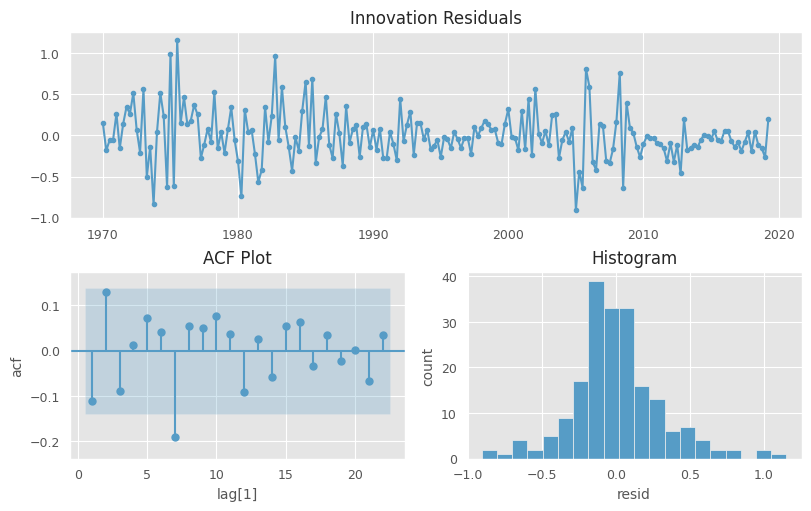

In [18]:
plot_diagnostics(forecaster=mf, n_lags=22)


In [19]:
residuals = mf.models_["LinearRegression"]._residuals
acorr_ljungbox(residuals, lags=[10])

,lb_stat,lb_pvalue
10,18.865,0.042


*   **Residuals vs. predictors:** We would expect the residuals to be randomly scattered without showing any systematic patterns. A simple and quick way to check this is to examine scatterplots of the residuals against each of the predictor variables. If these scatterplots show a pattern, then the relationship may be nonlinear and the model will need to be modified accordingly. 

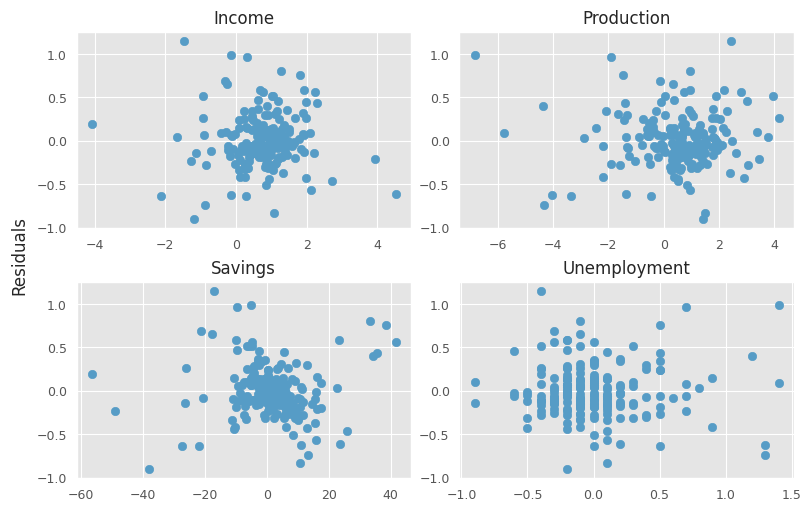

In [21]:
fig, axes = plt.subplots(nrows=2, ncols=2)
columns = ["Income", "Production", "Savings", "Unemployment"]
for ax, column in zip(axes.ravel(), columns):
    ax.scatter(us_change[column], residuals)
    ax.set(title=column)
fig.supylabel("Residuals")
plt.show()

*   **Residuals vs. fitted values:** Patterns here suggest heteroscedasticity (non-constant variance), which may require transforming the forecast variable.
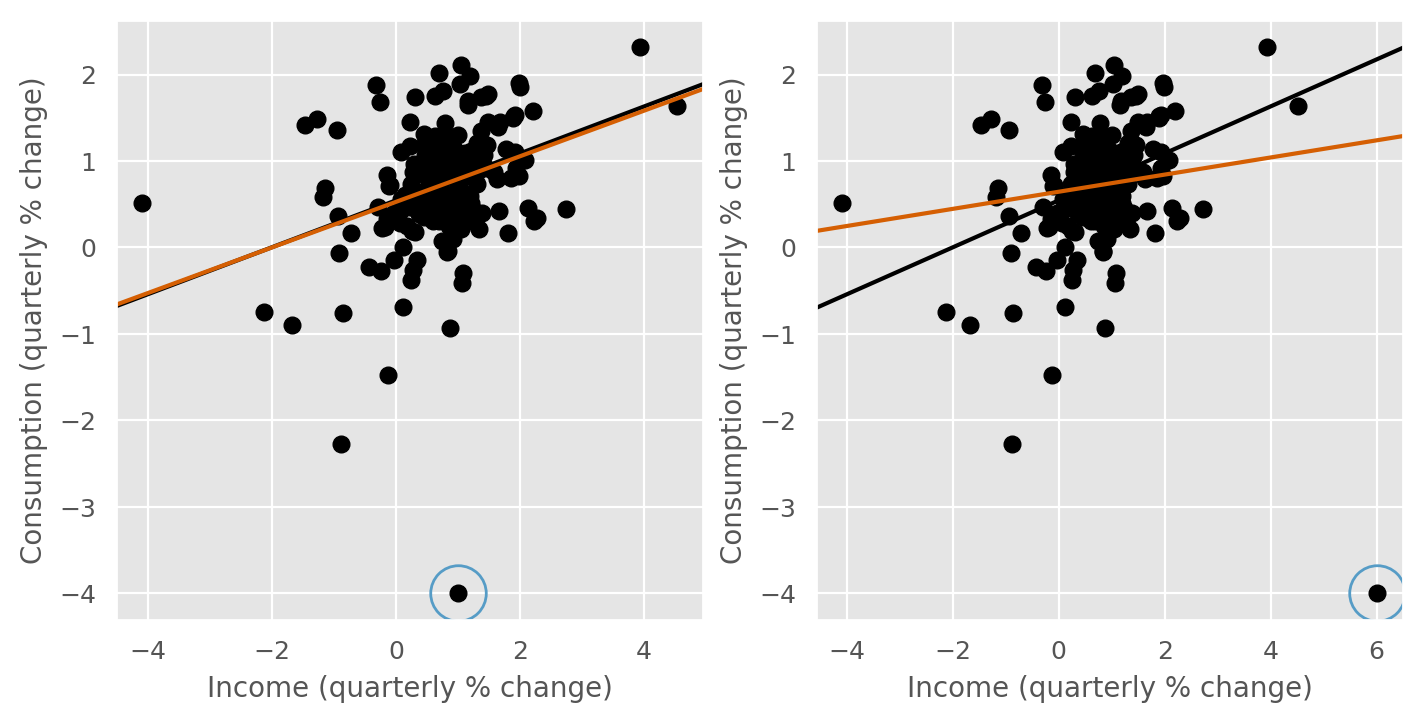

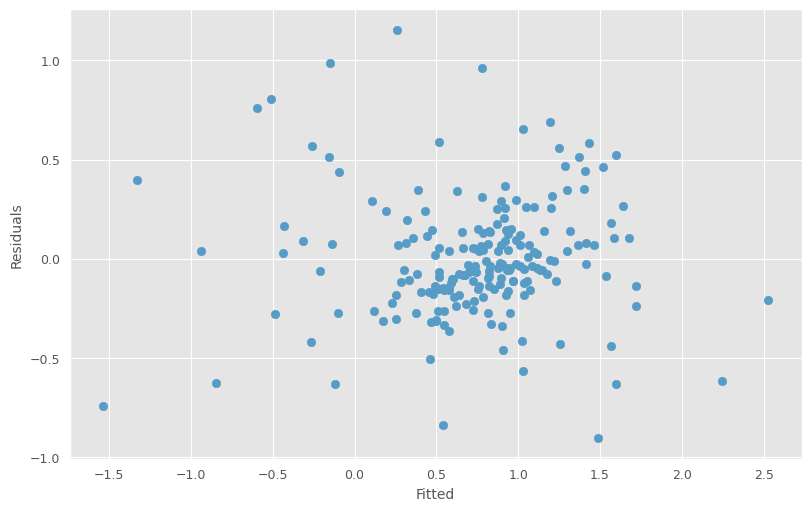

In [ ]:
fig, ax = plt.subplots()
ax.scatter(insample_forecasts, residuals)
ax.set(xlabel="Fitted", ylabel="Residuals")
plt.show()

*   **Outliers & Spurious regression:** Identify highly influential extreme values. Beware of regressing non-stationary (trending) time series against one another, as they can yield falsely high $R^2$ values despite having no actual relationship.

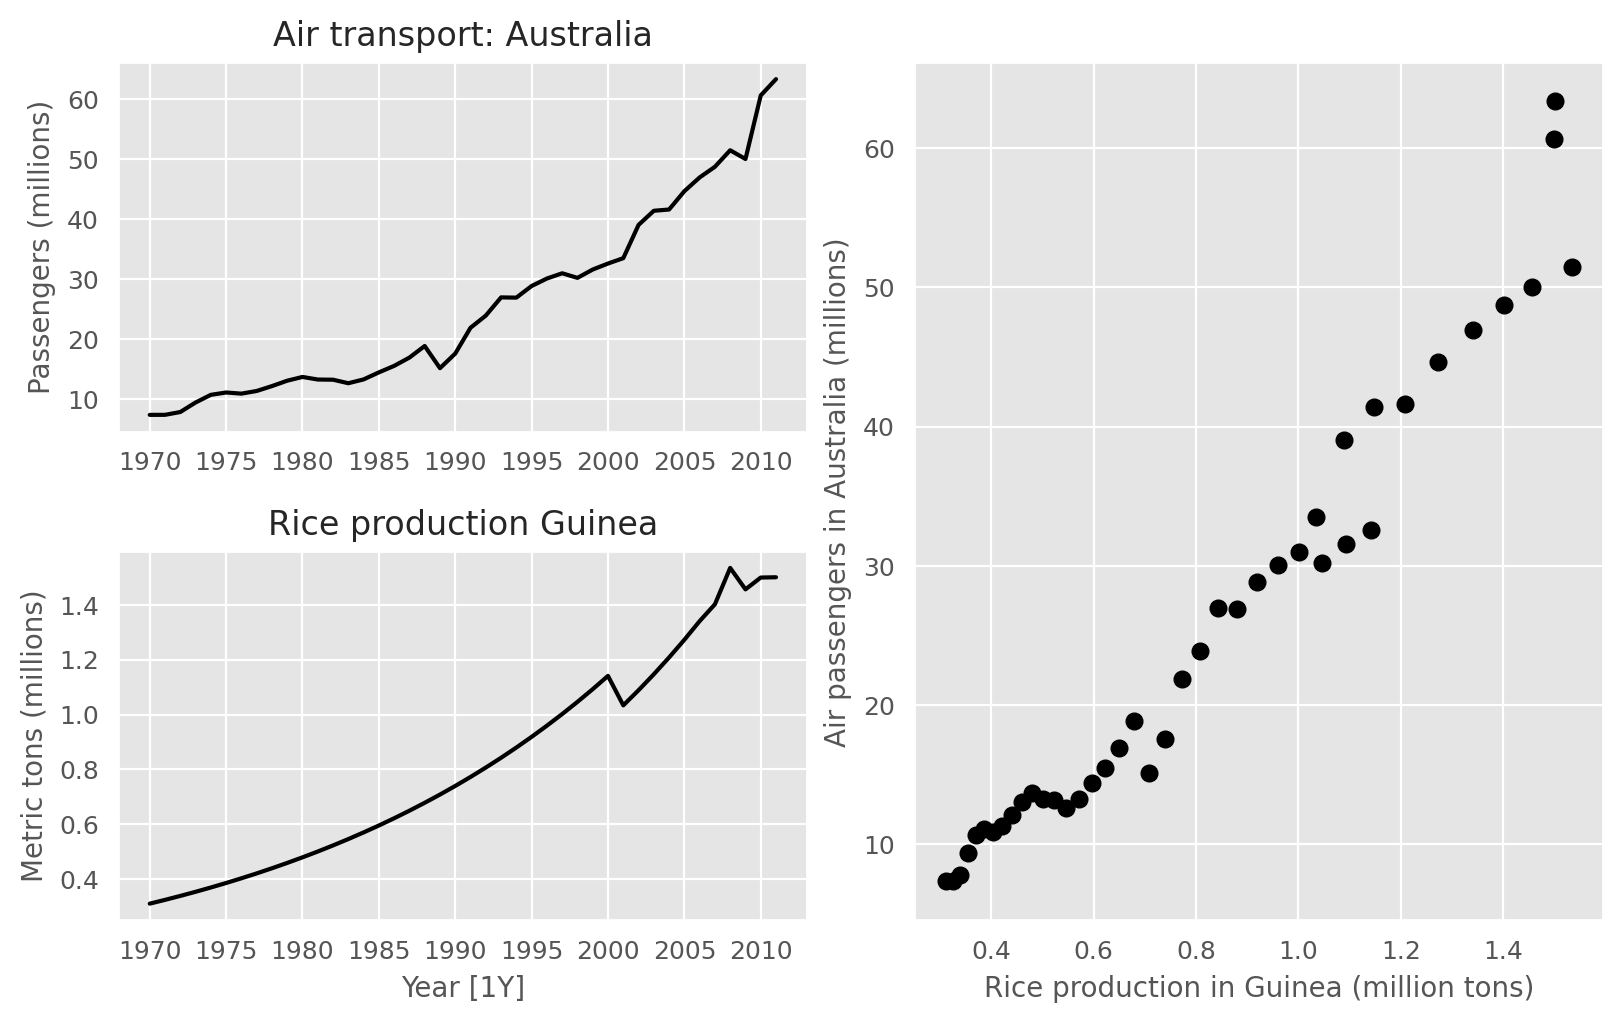

In [25]:
aus_airpassengers = pd.read_csv(DATA_DIR / "aus_airpassengers.csv",
    index_col=0, parse_dates=["Year"])
guinea_rice = pd.read_csv(DATA_DIR / "guinea_rice.csv",
    index_col=0, parse_dates=["Year"])
aus_airpassengers = (
    aus_airpassengers
    .merge(guinea_rice, on="Year")
    .assign(unique_id="AirPassengers")
)

mf = MLForecast(models=LinearRegression(), freq="YS")
mf.fit(aus_airpassengers, time_col="Year", target_col="Passengers",
    fitted=True, static_features=[])

insample = mf.forecast_fitted_values().assign(
    resid=lambda x: x["Passengers"] - x["LinearRegression"]
)
print_regression_summary_from_model(mf.models_['LinearRegression'])

Residuals:
    Min     1Q  Median     3Q     Max
 -5.945 -1.892  -0.327  1.862  10.421

Coefficients:
             Estimate  Std. Error  t value   Pr(>|t|)     
(Intercept)    -7.493       1.203   -6.229  2.253e-07  ***
Production     40.288       1.337   30.135  0.000e+00  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 3.239 on 40 degrees of freedom 
Multiple R-squared: 0.958,    Adjusted R-squared: 0.957 
F-statistic: 908.1 on 1 and 40 DF, p-value: 0


#### 7.4 Some useful predictors
Several specific types of predictors are highly useful for time series:
*   **Trend:** Modeled by setting $x_{1,t} = t$.
*   **Dummy variables:** Take the value $1$ or $0$ to indicate a categorical variable (e.g., a public holiday or an outlier). For seasonal data (e.g., quarterly), always use *one fewer* dummy variable than categories to avoid the "dummy variable trap".


Residuals:
     Min     1Q  Median     3Q     Max
 -42.903 -7.599  -0.459  7.991  21.789

Coefficients:
             Estimate  Std. Error  t value   Pr(>|t|)     
(Intercept)   441.800       3.734  118.333  0.000e+00  ***
trend          -0.340       0.067   -5.111  2.731e-06  ***
Quarter_2     -34.660       3.968   -8.734  9.104e-13  ***
Quarter_3     -17.822       4.022   -4.430  3.450e-05  ***
Quarter_4      72.796       4.023   18.095  0.000e+00  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 12.229 on 69 degrees of freedom 
Multiple R-squared: 0.924,    Adjusted R-squared: 0.920 
F-statistic: 210.7 on 4 and 69 DF, p-value: 0


,unique_id,ds,y,trend,Quarter_2,Quarter_3,Quarter_4
144,Beer,1992-03-01,443.0,1.0,False,False,False
145,Beer,1992-06-01,410.0,2.0,True,False,False
146,Beer,1992-09-01,420.0,3.0,False,True,False
147,Beer,1992-12-01,532.0,4.0,False,False,True
148,Beer,1993-03-01,433.0,5.0,False,False,False


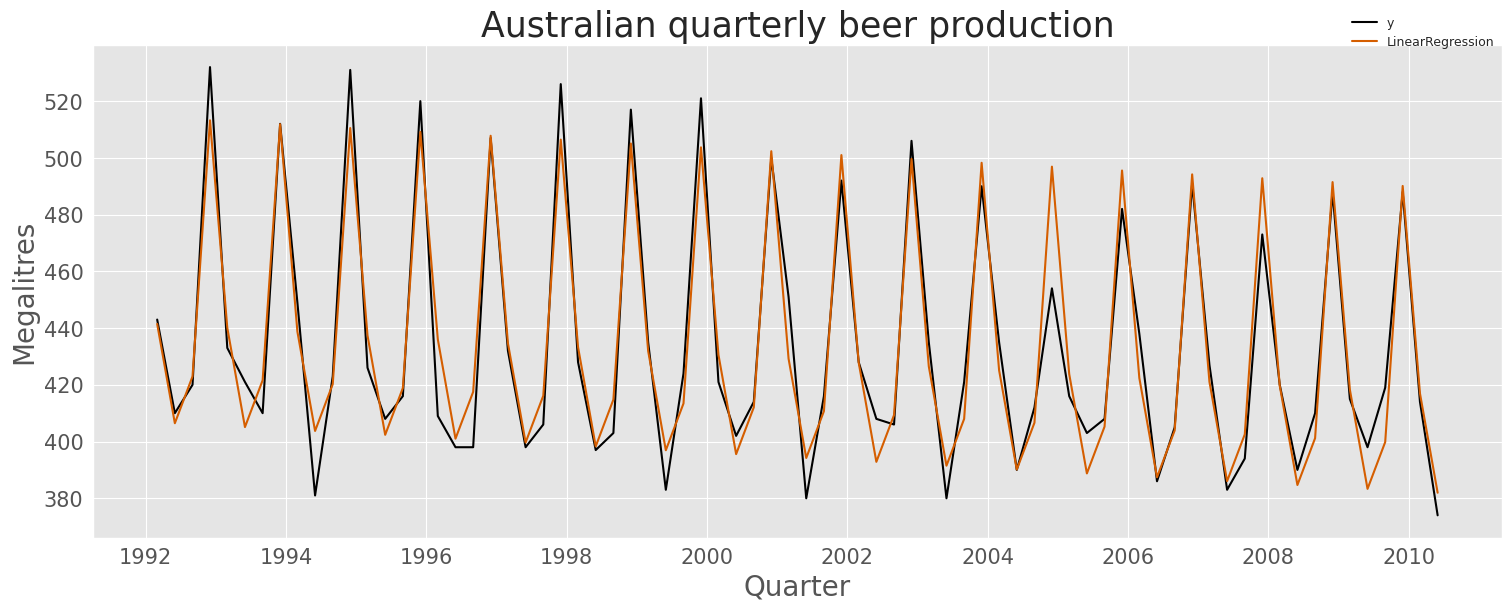

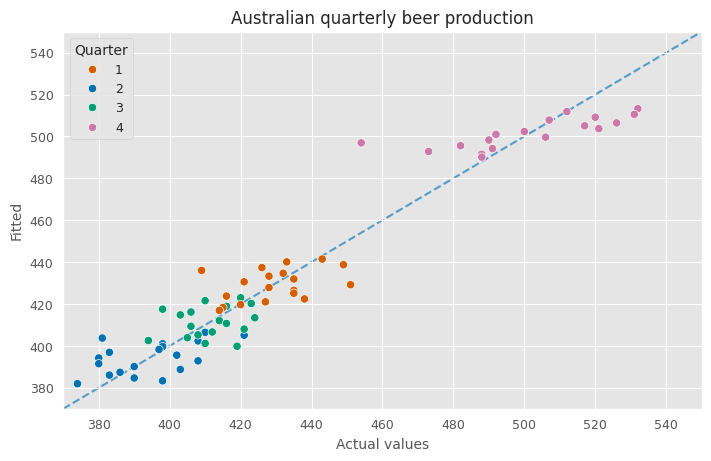

In [27]:
aus_production = pd.read_csv(DATA_DIR / "aus_production_formatted.csv",
    parse_dates=["ds"])
recent_beer = aus_production.loc[lambda x:
    (x["unique_id"] == "Beer") & (x["ds"] >= "1992")
]
plot_series(recent_beer,
    xlabel="Quarter [1Q]", ylabel="Megalitres",
    palette="black", title="Australian quarterly beer production") 


fit_beer = recent_beer.copy()
# Add trend
fit_beer, _ = trend(fit_beer, freq="QS-DEC")
# Add quarterly indicators
quarter = pd.get_dummies(fit_beer.ds.dt.quarter,
    prefix="Quarter", drop_first=True)
fit_beer = fit_beer.join(quarter)

mf = MLForecast(models=LinearRegression(), freq="QS-DEC")
mf.fit(fit_beer, fitted=True, static_features=[])
insample = mf.forecast_fitted_values()
print_regression_summary_from_model(mf.models_['LinearRegression'])
display(fit_beer.head())


fig1 = plot_series(
    fit_beer, insample.drop(columns="y"),
    xlabel="Quarter", ylabel="Megalitres",
    title="Australian quarterly beer production",
    palette="black_and_orange", rm_legend=False,)
display(fig1)

fig, ax = plt.subplots(figsize=(7, 4.5))
df = insample.assign(Quarter=lambda x: x["ds"].dt.quarter)
sns.scatterplot(data=df, x="y", y="LinearRegression",
    hue="Quarter", palette="r_colors")
ax.axline((0, 0), slope=1, linestyle="--", zorder=-1)
ax.set(
    xlim=(370, 550), ylim=(370, 550),
    xlabel="Actual values", ylabel="Fitted",
    title="Australian quarterly beer production",
)
plt.show()

*   **Intervention variables:** "Spikes" (effect lasts one period), "steps" (immediate and permanent shift), or piecewise trends (change in slope).
*   **Fourier series:** An alternative to seasonal dummies, ideal for long seasonal periods (like weekly data). The terms are specified as:
    $$ x_{1,t} = \sin\left(\frac{2\pi t}{m}\right), \quad x_{2,t} = \cos\left(\frac{2\pi t}{m}\right), \quad \dots $$

#### 7.5 Selecting predictors
Using $R^2$ to select predictors leads to over-fitting because adding *any* variable increases $R^2$. Instead, use accuracy metrics that penalize extra parameters:
*   **Adjusted $R^2$ ($\bar{R}^2$):** 
    $$ \bar{R}^2 = 1 - (1 - R^2)\frac{T-1}{T-k-1} $$
*   **Cross-validation (CV):** Computes leave-one-out MSE efficiently:
    $$ \text{CV} = \frac{1}{T}\sum_{t=1}^T [e_t / (1 - h_t)]^2 $$
*   **Akaike's Information Criterion (AIC):**
    $$ \text{AIC} = T \log\left(\frac{\text{SSE}}{T}\right) + 2(k+2) $$
*   **Corrected AIC (AICc):** (Recommended for small samples)
    $$ \text{AIC}_c = \text{AIC} + \frac{2(k+2)(k+3)}{T-k-3} $$
*   **Bayesian Information Criterion (BIC):**
    $$ \text{BIC} = T \log\left(\frac{\text{SSE}}{T}\right) + (k+2)\log(T) $$

When dealing with many possible predictors, use **stepwise regression** (backwards or forwards) rather than fitting all possible subset models.

##### Which measure should we use?

While $\bar{R}^2$ is widely used, and has been around longer than the other measures, its tendency to select too many predictor variables makes it less suitable for forecasting.

Many statisticians like to use the BIC because it has the feature that if there is a true underlying model, the BIC will select that model given enough data. However, in reality, there is rarely, if ever, a true underlying model, and even if there was a true underlying model, selecting that model will not necessarily give the best forecasts (because the parameter estimates may not be accurate).

Consequently, we recommend that one of the AICc, AIC, or CV statistics be used, each of which has forecasting as their objective. If the value of T is large enough, they will all lead to the same model. In most of the examples in this book, we use the AICc value to select the forecasting model.

#### 7.6 Forecasting with regression
Forecasting involves using the estimated coefficients to predict future values.
*   **Ex-ante vs Ex-post:** Ex-ante forecasts use only information available in advance (genuine forecasts). Ex-post forecasts use later, actual observations of the predictors (useful for studying model behavior).
*   **Prediction Intervals (Simple Regression):** The 95% interval incorporates the regression standard error ($\hat{\sigma}_e$) and the distance of the predictor from its historical mean ($\bar{x}$):
    $$ \hat{y} \pm 1.96 \hat{\sigma}_e \sqrt{1 + \frac{1}{T} + \frac{(x - \bar{x})^2}{(T-1)s_x^2}} $$

#### 7.7 Nonlinear regression
Nonlinear relationships can be modelled by transforming variables or using piecewise formulations.
*   **Log-log model:** 
    $$ \log y = \beta_0 + \beta_1 \log x + \varepsilon $$
*   **Piecewise linear (Regression Splines):** Introduces "knots" ($c$) where the slope bends.
    $$ x_2 = (x-c)_+ = \begin{cases} 0 & \text{if } x < c \\ x-c & \text{if } x \ge c \end{cases} $$
    *(This is especially useful for modelling a nonlinear trend that bends at time $\tau$).*

#### 7.8 Correlation, causation and forecasting
*   **Confounders:** A variable is useful for forecasting if it correlates with $y$, even if there is no direct causal link. Sometimes both variables are caused by a missing third variable (a confounder).
*   **Multicollinearity:** Occurs when predictors are highly correlated with each other. It makes it difficult to separate their individual effects and creates unreliable coefficient estimates. It strictly prevents model estimation if there is *perfect* correlation (like the dummy variable trap).

#### 7.9 Matrix formulation (Advanced)
A multiple regression model can be written in matrix form: $\mathbf{y} = \mathbf{X}\bm{\beta} + \bm{\varepsilon}$.
*   **Least squares estimation:** 
    $$ \hat{\bm{\beta}} = (\mathbf{X}'\mathbf{X})^{-1}\mathbf{X}'\mathbf{y} $$
*   **Fitted values:** 
    $$ \mathbf{\hat{y}} = \mathbf{H}\mathbf{y} $$
    *(Where the "hat-matrix" is $\mathbf{H} = \mathbf{X}(\mathbf{X}'\mathbf{X})^{-1}\mathbf{X}'$).*
*   **Forecasts and Variance:** For a future predictor vector $\mathbf{x}^*$:
    $$ \hat{y} = \mathbf{x}^*\hat{\bm{\beta}} $$
    $$ \text{Var}(\hat{y}) = \hat{\sigma}_e^2 \left[1 + \mathbf{x}^*(\mathbf{X}'\mathbf{X})^{-1}(\mathbf{x}^*)'\right] $$